In [22]:
import scanpy as sc
import pandas as pd

raw = pd.read_csv(
    'skin.tregs.exp.tsv',
    sep = '\t',
    index_col = 0
)
raw

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,...,MT-CYB,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAAGATGAGGACAGCT-2,0,0,0,0,0,0,0,0,0,0,...,6,0,0,0,0,0,0,0,0,0
AACTCTTCATGCAATC-2,0,0,0,0,0,0,0,0,0,0,...,12,0,0,0,0,0,0,0,0,0
AAGACCTTCAACGGCC-2,0,0,0,0,0,0,0,0,0,0,...,37,0,0,0,0,0,0,0,0,0
AAGGAGCTCAGCGACC-2,0,0,0,0,0,0,0,0,0,0,...,24,0,0,0,0,0,0,0,0,0
AATCCAGGTTGGTTTG-2,0,0,0,0,0,0,0,0,0,0,...,8,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCAATCTTCCGTGTGG-167,0,0,0,0,0,0,0,0,0,0,...,52,0,0,0,0,0,0,0,0,0
TCACTCGAGCTGAGCA-167,0,0,0,0,0,0,0,0,0,0,...,16,0,0,0,0,0,0,0,0,0
TCATGGAGTCCTTAAG-167,0,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
TCGCAGGAGTGAGTTA-167,0,0,0,0,0,0,0,0,0,0,...,29,0,0,0,0,0,0,0,0,0


In [23]:
corrected = pd.read_csv(
    'skin.tregs.exp.recombatseq.tsv',
    sep = '\t',
    index_col = 0
).T
corrected

,AL627309.1,AL669831.5,FAM87B,LINC00115,FAM41C,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,...,MT.CYB,BX004987.1,AC145212.1,MAFIP,AC011043.1,AL592183.1,AC007325.4,AL354822.1,AC004556.1,AC240274.1
AAAGATGAGGACAGCT-2,0,0,0,0,0,0,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0
AACTCTTCATGCAATC-2,0,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
AAGACCTTCAACGGCC-2,0,0,0,0,0,0,0,0,0,0,...,21,0,0,0,0,0,0,0,0,0
AAGGAGCTCAGCGACC-2,0,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
AATCCAGGTTGGTTTG-2,0,0,0,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCAATCTTCCGTGTGG-167,0,0,0,0,0,0,0,0,0,0,...,32,0,0,0,0,0,0,0,0,0
TCACTCGAGCTGAGCA-167,0,0,0,0,0,0,0,0,0,0,...,7,0,0,0,0,0,0,0,0,0
TCATGGAGTCCTTAAG-167,0,0,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,0,0,0,0
TCGCAGGAGTGAGTTA-167,0,0,0,0,0,0,0,0,0,0,...,15,0,0,0,0,0,0,0,0,0


In [24]:
meta = pd.read_csv(
    'skin.tregs.meta.tsv',
    sep = '\t',
    index_col = 0
)
meta

,sample_id,patient_id,status,tissue,cell_fraction,doublet,doublet_score,nFeature_RNA,nCount_RNA,percent_mt,...,qc_pass,_scvi_batch,_scvi_labels,leiden_scvi_0.1,coarse_cell_types,leiden_scvi_0.4,dataset,sat1_status,clustering,sat1_status_majority_vote
AAAGATGAGGACAGCT-2,4820STDY7388992,s1,normal,dermis,dermal lymphoid,False,6.867039e+00,1293,3612.0,3.073090,...,True,0,0,1,Tcell,1,Psoriasis,SAT1_lo,85,SAT1_hi
AACTCTTCATGCAATC-2,4820STDY7388992,s1,normal,dermis,dermal lymphoid,False,4.914250e-07,909,2192.0,4.835766,...,True,0,0,1,Tcell,1,Psoriasis,SAT1_lo,116,SAT1_hi
AAGACCTTCAACGGCC-2,4820STDY7388992,s1,normal,dermis,dermal lymphoid,False,4.914250e-07,961,2746.0,7.174071,...,True,0,0,1,Tcell,1,Psoriasis,SAT1_lo,52,SAT1_lo
AAGGAGCTCAGCGACC-2,4820STDY7388992,s1,normal,dermis,dermal lymphoid,False,4.914250e-07,860,1972.0,9.330629,...,True,0,0,1,Tcell,1,Psoriasis,SAT1_lo,30,SAT1_lo
AATCCAGGTTGGTTTG-2,4820STDY7388992,s1,normal,dermis,dermal lymphoid,False,4.914250e-07,767,2052.0,6.335283,...,True,0,0,1,Tcell,1,Psoriasis,SAT1_lo,5,SAT1_lo
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCAATCTTCCGTGTGG-167,P14_V02_Skin_NL,P14,sarcoidosis,Skin_NL,NaN,False,1.180772e+00,1595,5557.0,7.791974,...,True,34,0,1,Tcell,1,Sarcoidosis,SAT1_lo,15,SAT1_lo
TCACTCGAGCTGAGCA-167,P14_V02_Skin_NL,P14,sarcoidosis,Skin_NL,NaN,False,8.114316e-01,1361,4208.0,3.849810,...,True,34,0,1,Tcell,1,Sarcoidosis,SAT1_hi,0,SAT1_hi
TCATGGAGTCCTTAAG-167,P14_V02_Skin_NL,P14,sarcoidosis,Skin_NL,NaN,False,1.560643e+00,1996,5808.0,2.479339,...,True,34,0,1,Tcell,1,Sarcoidosis,SAT1_hi,71,SAT1_hi
TCGCAGGAGTGAGTTA-167,P14_V02_Skin_NL,P14,sarcoidosis,Skin_NL,NaN,False,1.560643e+00,1781,5724.0,4.245283,...,True,34,0,1,Tcell,1,Sarcoidosis,SAT1_hi,39,SAT1_lo


In [25]:
import anndata as ad


adatas = {}
for k, df in zip(['raw', 'corr',], [raw, corrected]):
    adatas[k] = ad.AnnData(
        X = df,
        obs = meta,
        var = pd.DataFrame(index = df.columns)
    )
adatas

{'raw': AnnData object with n_obs × n_vars = 9773 × 18476
     obs: 'sample_id', 'patient_id', 'status', 'tissue', 'cell_fraction', 'doublet', 'doublet_score', 'nFeature_RNA', 'nCount_RNA', 'percent_mt', 'percent_ribo', 'qc_pass', '_scvi_batch', '_scvi_labels', 'leiden_scvi_0.1', 'coarse_cell_types', 'leiden_scvi_0.4', 'dataset', 'sat1_status', 'clustering', 'sat1_status_majority_vote',
 'corr': AnnData object with n_obs × n_vars = 9773 × 18476
     obs: 'sample_id', 'patient_id', 'status', 'tissue', 'cell_fraction', 'doublet', 'doublet_score', 'nFeature_RNA', 'nCount_RNA', 'percent_mt', 'percent_ribo', 'qc_pass', '_scvi_batch', '_scvi_labels', 'leiden_scvi_0.1', 'coarse_cell_types', 'leiden_scvi_0.4', 'dataset', 'sat1_status', 'clustering', 'sat1_status_majority_vote'}

In [26]:
for k, adata in adatas.items():
    print(k)
    adata.layers['counts'] = adata.X.copy()
    tmp = adata
    sc.pp.normalize_total(tmp)
    sc.pp.log1p(tmp)
    sc.pp.highly_variable_genes(
        tmp,
        n_top_genes = 4000,
        flavor = "seurat_v3",
        layer = 'counts'
    )
    sc.pp.pca(
        tmp, 
        n_comps = 40, 
        svd_solver = 'arpack',
        mask_var = 'highly_variable'
    )
    sc.pp.neighbors(
        tmp,
        use_rep = 'X_pca'
    )
    sc.tl.umap(tmp)

raw
corr


raw
corr


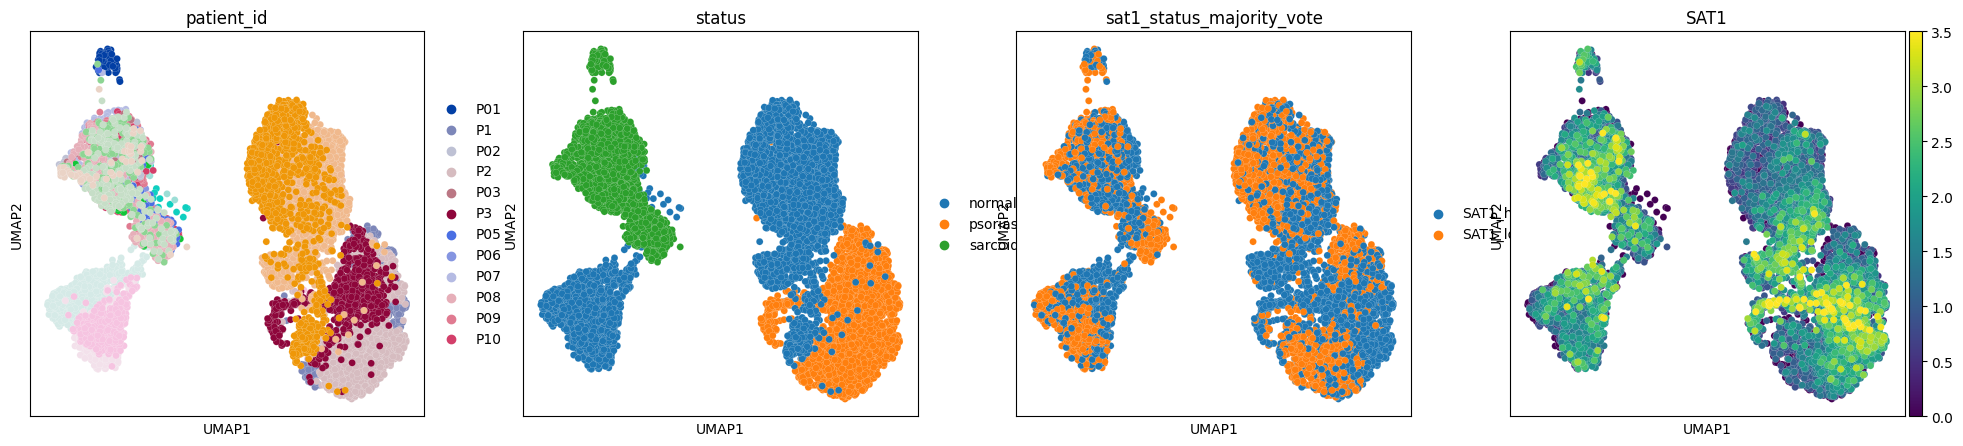

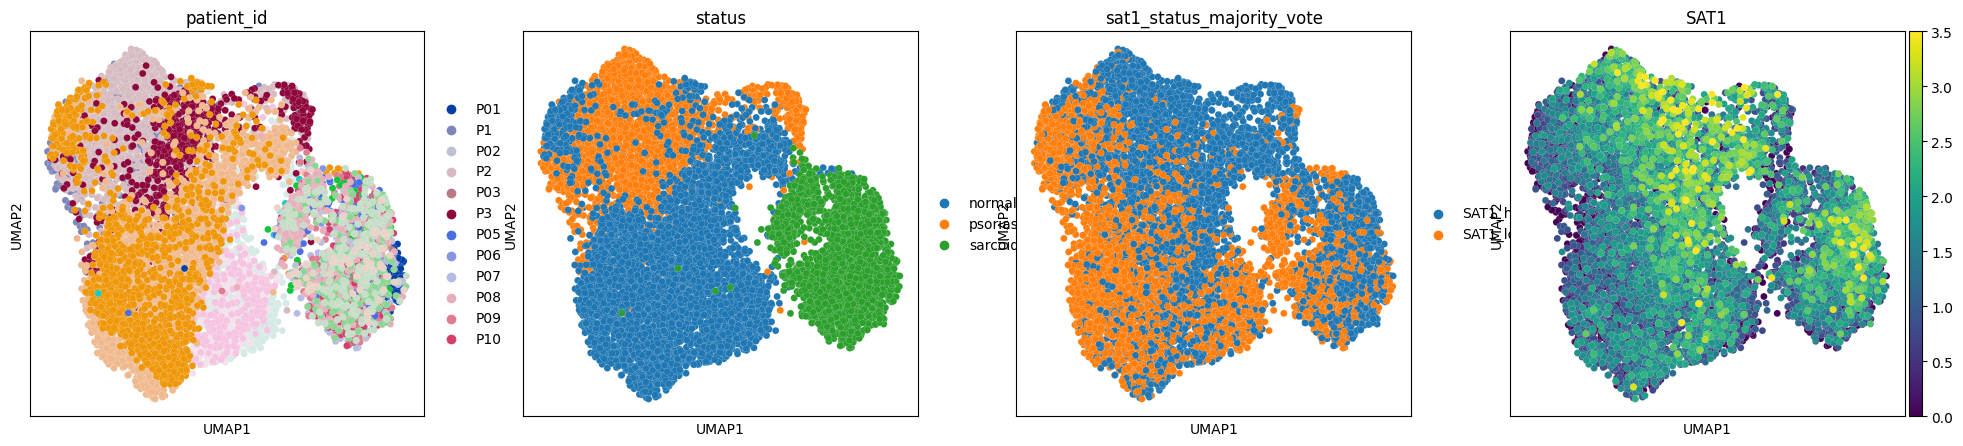

In [28]:
for k, adata in adatas.items():
    print(k)
    fig = sc.pl.umap(
        adata,
        color = ['patient_id', 'status', 'sat1_status_majority_vote', 'SAT1'],
        return_fig = True,
        edgecolor = 'white',
        size = 100,
        lw = 0.1,
        vmax = 3.5
    )
    fig.set_figwidth(24)
    fig.set_figheight(5)
    # fig.savefig(f'tregs.umap.{k}.pdf')

In [ ]:
from sctools import plot


for k, adata in adatas.items():
    plot.misc.generate_and_save_for_figure(
        adata,
        {
            'patient_id': (None, None),
            'status': ('colorblind', None),
            'sat1_status_majority_vote': ({'SAT1_hi': 'tab:orange', 'SAT1_lo': 'tab:blue'}, None),
            'SAT1': ('viridis', 3.5)
        },
        f'tregs.{k}.umap' + '.{0}.png',
        f'tregs.{k}.umap' + '.{0}.legend.pdf',
        size = 100,
        edgecolor = 'k',
        linewidths = 0.1
    )

In [30]:
raw_degs = pd.read_csv(
    'skin.tregs.exp.de.all.tsv',
    sep = '\t'
)
raw_degs.set_index('gene', inplace = True)
raw_degs

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,significant
gene,,,,,,
DUSP2,0.000000,3.548229,0.468,0.083,0.0,True
JUND,0.000000,3.378924,0.506,0.181,0.0,True
RPS4Y1,0.000000,13.898742,0.324,0.000,0.0,True
MT.ND4L,0.000000,-2.081702,0.468,0.751,0.0,True
TSC22D3,0.000000,-1.677112,0.784,0.974,0.0,True
...,...,...,...,...,...,...
RPS16,0.682807,0.001203,0.994,0.995,1.0,False
MOB2,0.744413,-0.037434,0.121,0.122,1.0,False
C6orf48,0.744941,0.007169,0.323,0.316,1.0,False


In [31]:
corr_degs = pd.read_csv(
    'skin.tregs.exp.recombatseq.de.all.tsv',
    sep = '\t'
)
corr_degs.set_index('gene', inplace = True)
corr_degs

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,significant
gene,,,,,,
DUSP2,0.000000e+00,2.609757,0.468,0.083,0.000000e+00,True
RPS4Y1,0.000000e+00,12.470749,0.324,0.000,0.000000e+00,True
ITM2C,3.421838e-292,-0.605122,0.273,0.616,6.322188e-288,True
TXNIP,4.978287e-281,-0.839315,0.382,0.739,9.197882e-277,True
SLAMF1,1.305874e-268,-1.306195,0.205,0.544,2.412734e-264,True
...,...,...,...,...,...,...
RPS6KA3,7.559081e-01,-0.086326,0.099,0.102,1.000000e+00,False
RPL34,7.607831e-01,0.018708,0.999,0.999,1.000000e+00,False
RPL11,8.099399e-01,0.017128,0.999,0.999,1.000000e+00,False


In [33]:
(
    len(raw_degs[raw_degs.significant]), 
    len(corr_degs[corr_degs.significant]),
    len(
        set(raw_degs[raw_degs.significant].index) & 
        set(corr_degs[corr_degs.significant].index)
    )
)

(1119, 833, 826)

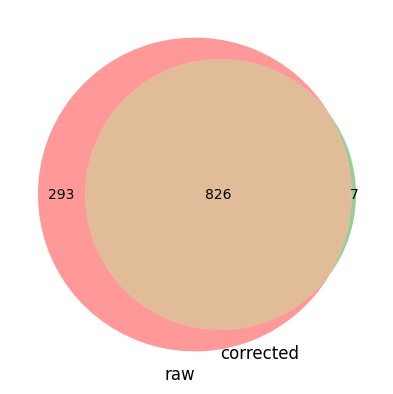

In [73]:
from matplotlib_venn import venn2

fig, ax = plt.subplots()
venn2(
    (
        set(raw_degs[raw_degs.significant].index), 
        set(corr_degs[corr_degs.significant].index)
    ),
    set_labels = ['raw', 'corrected'],
    ax = ax
)
fig.savefig('degoverlap.pdf')

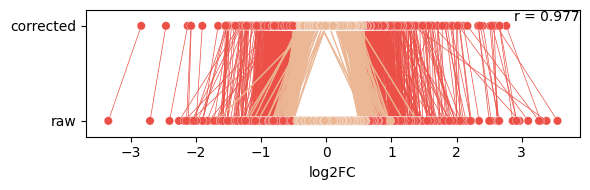

In [68]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, ax = plt.subplots()
df = raw_degs.merge(
    corr_degs,
    left_index = True,
    right_index = True,
    how = 'inner',
    suffixes = ['_raw', '_corrected']
)
df = df.query(
    'avg_log2FC_raw < 4.5'
)
ypos = [-0.3, 0.3]
for gene, row in df.iterrows():
    if not row.significant_raw:
        continue

    both_significant = (row.significant_raw & row.significant_corrected)
    c = '#EBB795' if not both_significant else '#EB4F46'
    zorder = 2 if not both_significant else 1
    lw = 1 if not both_significant else 0.5
    ax.plot(
        [row.avg_log2FC_raw, row.avg_log2FC_corrected],
        ypos,
        c = c,
        # alpha = 0.5,
        lw = lw,
        zorder = zorder
    )
    
for i, k in zip(ypos, ['raw', 'corrected']):
    ax.scatter(
        y = [i for _ in range(len(df))],
        x = df[f'avg_log2FC_{k}'],
        c = ['#EBB795' if not b else '#EB4F46' for b in df[f'significant_{k}']],
        edgecolor = 'white',
        lw = 0.2,
        zorder = 4
    )
res = spearmanr(df.avg_log2FC_raw, df.avg_log2FC_corrected)
ax.set_xlabel('log2FC')
ax.set_yticks(ypos)
ax.set_yticklabels(['raw', 'corrected'])
ax.set_ylim(-0.4, 0.4)
ax.text(
    ax.get_xlim()[-1],
    ax.get_ylim()[-1],
    f'r = {res.statistic:.3f}',
    ha = 'right',
    va = 'top'
)
fig.set_figwidth(6)
fig.set_figheight(2)
fig.tight_layout()
fig.savefig('degcorrelation.pdf')

In [3]:
import scanpy as sc
import pandas as pd
from scipy.sparse import csr_matrix


def line_to_sparse(line):
    values = line.rstrip().split()
    row_idx = line[0]
    index, data = [], []
    for c, val in enumerate(values[1:]):
        if val == '0':
            continue
        data.append(int(val))
        index.append(c)
    return data, index, row_idx


def read_data_as_sparse(filename, shape):
    with open(filename, 'rt') as file:
        colnames = file.readline().rstrip().split()
        indptr = [0]
        rownames, indices, data = [], [], []
        for line in file:
            d, index, row_name = line_to_sparse(line)
            rownames.append(row_name)
            indices.extend(index)
            indptr.append(len(indices))
            data.extend(d)

    return csr_matrix((data, indices, indptr), shape = shape), rownames, colnames

/lisc/data/scratch/menche/daniel/conda/envs/scnova/lib/python3.13/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [ ]:
# raw_X, raw_rownames, raw_colnames = read_data_as_sparse('skin.inflammatory.exp.tsv', (332546, 20912))
# raw_X

In [ ]:
# corr_X, corr_rownames, corr_colnames = read_data_as_sparse('skin.inflammatory.exp.recombatseq.tsv', (20912, 332546))
# corr_X

In [ ]:
# meta = pd.read_csv(
#     'skin.inflammatory.meta.tsv',
#     sep = '\t',
#     index_col = 0
# )
# meta

In [ ]:
# import anndata as ad

# for k, X in zip(['raw', 'recombatseq'], [raw_X, corr_X.T]):
#     adata = ad.AnnData(
#         X = X,
#         obs = meta,
#         var = pd.DataFrame(index = raw_rownames)
#     )
    
#     adata.write(f'skin.inflammatory.{k}.h5ad')

In [1]:
import anndata as ad


adatas = {}
for k in ['raw', 'recombatseq']:
    adatas[k] = ad.read_h5ad(
        f'skin.inflammatory.{k}.h5ad'
    )
adatas

/lisc/data/scratch/menche/daniel/conda/envs/scnova/lib/python3.13/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


{'raw': AnnData object with n_obs × n_vars = 332546 × 20912
     obs: 'sample_id', 'patient_id', 'status', 'tissue', 'cell_fraction', 'doublet', 'doublet_score', 'nFeature_RNA', 'nCount_RNA', 'percent_mt', 'percent_ribo', 'qc_pass', '_scvi_batch', '_scvi_labels', 'leiden_scvi_0.1', 'coarse_cell_types', 'leiden_scvi_0.75', 'cell_type',
 'recombatseq': AnnData object with n_obs × n_vars = 332546 × 20912
     obs: 'sample_id', 'patient_id', 'status', 'tissue', 'cell_fraction', 'doublet', 'doublet_score', 'nFeature_RNA', 'nCount_RNA', 'percent_mt', 'percent_ribo', 'qc_pass', '_scvi_batch', '_scvi_labels', 'leiden_scvi_0.1', 'coarse_cell_types', 'leiden_scvi_0.75', 'cell_type'}

In [4]:
for k, adata in adatas.items():
    print(k)
    adata.layers['counts'] = adata.X.copy()
    tmp = adata
    sc.pp.normalize_total(tmp)
    sc.pp.log1p(tmp)
    sc.pp.highly_variable_genes(
        tmp,
        n_top_genes = 4000,
        flavor = "seurat_v3",
        layer = 'counts'
    )
    sc.pp.pca(
        tmp, 
        n_comps = 40, 
        svd_solver = 'arpack',
        mask_var = 'highly_variable'
    )
    sc.pp.neighbors(
        tmp,
        use_rep = 'X_pca'
    )
    sc.tl.umap(tmp)

raw


/lisc/data/scratch/menche/daniel/conda/envs/scnova/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


recombatseq


raw
recombatseq


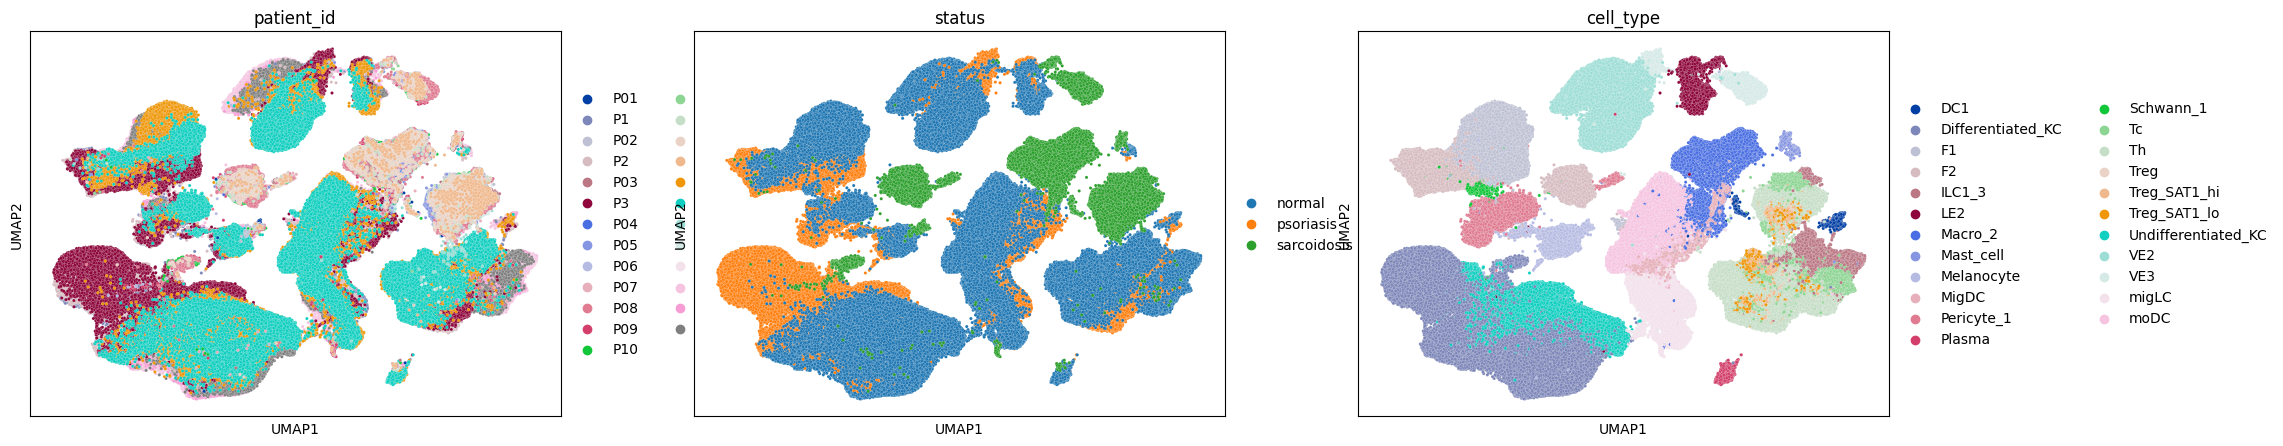

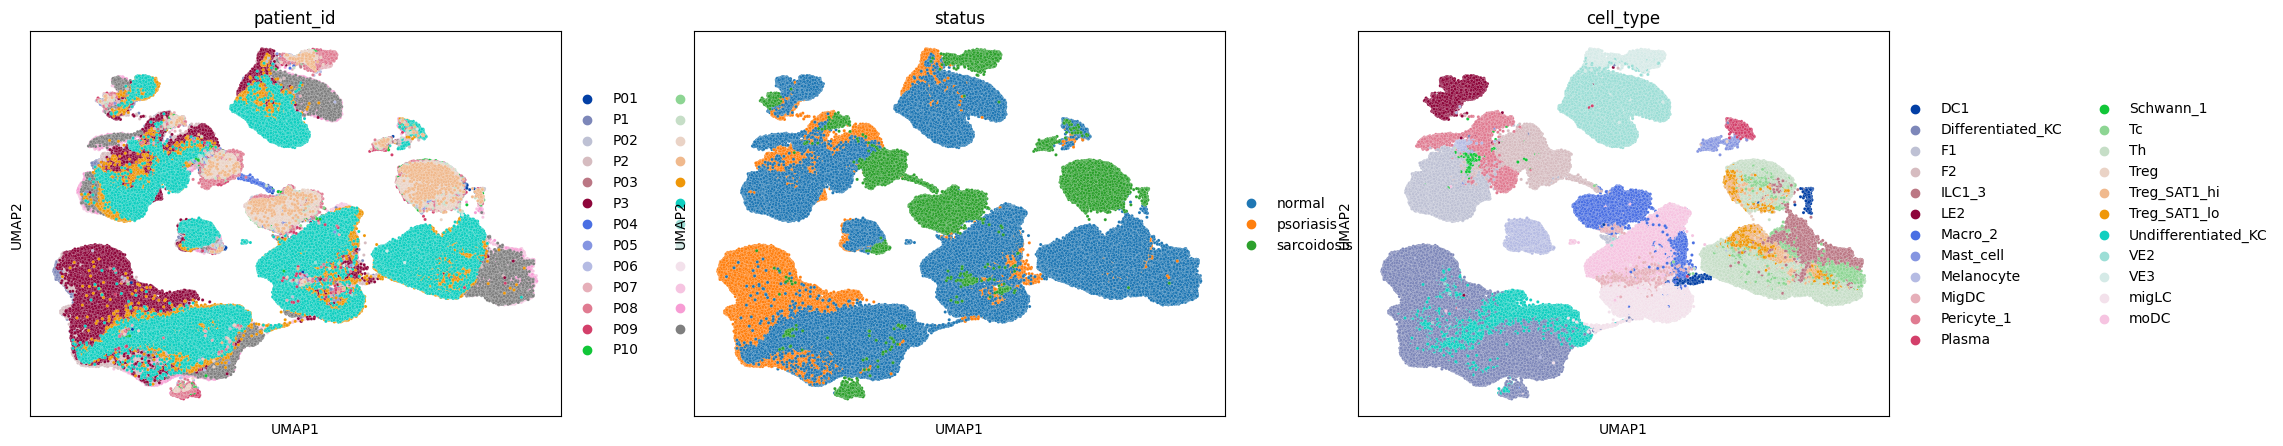

In [6]:
for k, adata in adatas.items():
    print(k)
    fig = sc.pl.umap(
        adata,
        color = ['patient_id', 'status', 'cell_type'],
        return_fig = True,
        edgecolor = 'white',
        size = 20,
        lw = 0.1
    )
    fig.set_figwidth(24)
    fig.set_figheight(5)
    # fig.savefig(f'full.umap.{k}.pdf')

In [8]:
from sctools import plot

for k, adata in adatas.items():
    plot.misc.generate_and_save_for_figure(
        adata,
        {
            'patient_id': (None, None),
            'status': ('colorblind', None),
            'cell_type': (None, None),
        },
        f'full.{k}.umap' + '.{0}.png',
        f'full.{k}.umap' + '.{0}.legend.pdf',
        size = 10,
        edgecolor = 'k',
        linewidths = 0.05
    )